<a href="https://colab.research.google.com/github/ramyaa-hegde/flyrank-ml-internship-tasks/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ramyaa-hegde/flyrank-ml-internship-tasks/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question and supported decision

**Research question:** Using February public-safe search and engagement signals, can a Random Forest rank eligible pseudonymized content items that will have below-benchmark CTR in March more effectively than a transparent February-only review baseline on held-out clients?

**Decision supported:** A content or SEO team uses the ranked output to decide which visible items deserve manual CTR review first. Review means checking title, snippet, search intent, page context, and tracking—not automatically changing a page.

**Outcome definition:** “Below benchmark” means an item’s observed March CTR is below the median CTR of comparable items in its March search-position bucket. This is an observational, position-adjusted proxy for review opportunity, not evidence that an edit will cause more clicks.

In [9]:
import pandas as pd

capstone_scope = pd.DataFrame(
    {
        "capstone_component": [
            "Decision",
            "Prediction inputs",
            "Outcome proxy",
            "Validation population",
            "Output",
        ],
        "definition": [
            "Prioritize a small human review queue for possible CTR opportunities.",
            "February aggregated search and engagement features only.",
            "March CTR below the median CTR for the item's March position bucket.",
            "Whole pseudonymized clients held out from training.",
            "Ranked decision-support labels; no automated site changes.",
        ],
    }
)

print("=== Capstone question and scope ===")
display(capstone_scope)

=== Capstone question and scope ===


,capstone_component,definition
0,Decision,Prioritize a small human review queue for poss...
1,Prediction inputs,February aggregated search and engagement feat...
2,Outcome proxy,March CTR below the median CTR for the item's ...
3,Validation population,Whole pseudonymized clients held out from trai...
4,Output,Ranked decision-support labels; no automated s...


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data release and public-safe scope

The capstone uses the FlyRank ML Internship warehouse table `fact_content_daily_performance` at daily pseudonymized client-content grain.

- **February 2026:** feature window for model inputs.
- **March 2026:** later outcome window used to define the position-adjusted CTR proxy label.
- **April 2026:** later scoring window used for the action playbook.

Only aggregated public-safe search and engagement signals are used. `client_hash_id` and `content_hash_id` are pseudonymized identifiers used for grouping, validation, and row identity—not model features. Raw URLs, titles, private queries, credentials, product flags, and row-level recommendation exports are excluded.

In [10]:
import duckdb
import pandas as pd
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")

con = duckdb.connect()
con.execute(
    f"CREATE OR REPLACE SECRET hf_secret "
    f"(TYPE HUGGINGFACE, TOKEN '{hf_token}')"
)

FEB = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-02/*.parquet"
)

MARCH = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-03/*.parquet"
)

APRIL = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-04/*.parquet"
)

release_summary = con.execute(f"""
    SELECT
        'February 2026 features' AS window,
        COUNT(*) AS daily_records,
        COUNT(DISTINCT client_hash_id) AS pseudonymized_clients,
        COUNT(DISTINCT content_hash_id) AS pseudonymized_content_items,
        SUM(
            CASE WHEN gsc_data_available IS TRUE THEN 1 ELSE 0 END
        ) AS gsc_available_records
    FROM read_parquet('{FEB}')

    UNION ALL

    SELECT
        'March 2026 outcome label' AS window,
        COUNT(*) AS daily_records,
        COUNT(DISTINCT client_hash_id) AS pseudonymized_clients,
        COUNT(DISTINCT content_hash_id) AS pseudonymized_content_items,
        SUM(
            CASE WHEN gsc_data_available IS TRUE THEN 1 ELSE 0 END
        ) AS gsc_available_records
    FROM read_parquet('{MARCH}')

    UNION ALL

    SELECT
        'April 2026 action scoring' AS window,
        COUNT(*) AS daily_records,
        COUNT(DISTINCT client_hash_id) AS pseudonymized_clients,
        COUNT(DISTINCT content_hash_id) AS pseudonymized_content_items,
        SUM(
            CASE WHEN gsc_data_available IS TRUE THEN 1 ELSE 0 END
        ) AS gsc_available_records
    FROM read_parquet('{APRIL}')
""").df()

print("=== Public-safe warehouse release summary ===")
display(release_summary)

print(
    "All numbers are aggregate release statistics. "
    "No raw URLs, titles, private queries, client names, or row-level "
    "recommendation data are displayed or exported."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== Public-safe warehouse release summary ===


,window,daily_records,pseudonymized_clients,pseudonymized_content_items,gsc_available_records
0,February 2026 features,7355108,54,321546,2621783.0
1,March 2026 outcome label,9841378,55,331437,3611061.0
2,April 2026 action scoring,10424730,61,362172,3901060.0


All numbers are aggregate release statistics. No raw URLs, titles, private queries, client names, or row-level recommendation data are displayed or exported.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology: features, proxy label, baseline, and validation

The model uses only February aggregated features available before the March outcome window: impressions, average position, scroll events, social sessions, observed-day coverage, GA4 availability, and a February position bucket. Missing engagement values are handled with median imputation plus missingness indicators; the February position bucket is one-hot encoded.

The outcome proxy is whether an eligible item’s observed March CTR is below the median CTR of items in its March position bucket. This is a position-adjusted observational review signal, not a causal measure of optimization success.

The transparent baseline ranks February items in positions 4–20 by February impression volume. The Random Forest and this baseline are compared on the same held-out pseudonymized clients using Precision@20, Average Precision, and ROC-AUC.

No identifiers, March outcome fields, product flags, action labels, or future-window fields are model inputs. The population

In [11]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Build February features and the later March position-adjusted CTR proxy.
model_df = con.execute(f"""
    WITH february_features AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS feb_impressions,
            AVG(NULLIF(gsc_avg_position, 0)) AS feb_avg_position,
            SUM(CASE WHEN ga4_data_available IS TRUE THEN scroll_events END)
                AS feb_scroll_events,
            SUM(CASE WHEN ga4_data_available IS TRUE THEN sessions_social END)
                AS feb_sessions_social,
            COUNT(*) AS feb_observed_days,
            MAX(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END)
                AS has_ga4_data
        FROM read_parquet('{FEB}')
        WHERE gsc_data_available IS TRUE
        GROUP BY 1, 2
    ),
    march_outcomes AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS march_impressions,
            SUM(gsc_clicks)::DOUBLE
                / NULLIF(SUM(gsc_impressions), 0) AS march_ctr,
            AVG(NULLIF(gsc_avg_position, 0)) AS march_avg_position
        FROM read_parquet('{MARCH}')
        WHERE gsc_data_available IS TRUE
        GROUP BY 1, 2
    ),
    march_bucketed AS (
        SELECT *,
            CASE
                WHEN march_avg_position <= 3 THEN '1-3'
                WHEN march_avg_position <= 10 THEN '4-10'
                WHEN march_avg_position <= 20 THEN '11-20'
                WHEN march_avg_position <= 50 THEN '21-50'
                ELSE '51+'
            END AS march_position_bucket
        FROM march_outcomes
        WHERE march_impressions >= 100
          AND march_avg_position IS NOT NULL
    ),
    labelled_march AS (
        SELECT *,
            MEDIAN(march_ctr) OVER (
                PARTITION BY march_position_bucket
            ) AS march_bucket_median_ctr
        FROM march_bucketed
    )
    SELECT
        f.client_hash_id,
        f.content_hash_id,
        f.feb_impressions,
        f.feb_avg_position,
        f.feb_scroll_events,
        f.feb_sessions_social,
        f.feb_observed_days,
        f.has_ga4_data,
        CASE
            WHEN f.feb_avg_position <= 3 THEN '1-3'
            WHEN f.feb_avg_position <= 10 THEN '4-10'
            WHEN f.feb_avg_position <= 20 THEN '11-20'
            WHEN f.feb_avg_position <= 50 THEN '21-50'
            ELSE 'missing_or_51+'
        END AS feb_position_bucket,
        CASE
            WHEN m.march_ctr < m.march_bucket_median_ctr THEN 1
            ELSE 0
        END AS target
    FROM february_features AS f
    INNER JOIN labelled_march AS m
        USING (client_hash_id, content_hash_id)
    WHERE f.feb_impressions >= 100
      AND f.feb_avg_position IS NOT NULL
""").df()

feature_columns = [
    "feb_impressions",
    "feb_avg_position",
    "feb_scroll_events",
    "feb_sessions_social",
    "feb_observed_days",
    "has_ga4_data",
    "feb_position_bucket",
]

numeric_features = [
    "feb_impressions",
    "feb_avg_position",
    "feb_scroll_events",
    "feb_sessions_social",
    "feb_observed_days",
    "has_ga4_data",
]

X = model_df[feature_columns].copy()
y = model_df["target"].copy()
groups = model_df["client_hash_id"].copy()

# Stratified grouped client holdout: entire clients stay in either train or validation.
splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

candidate_splits = list(splitter.split(X, y, groups))
overall_target_rate = y.mean()

train_index, validation_index = min(
    candidate_splits,
    key=lambda split: abs(y.iloc[split[1]].mean() - overall_target_rate),
)

X_train = X.iloc[train_index].copy()
X_val = X.iloc[validation_index].copy()
y_train = y.iloc[train_index].copy()
y_val = y.iloc[validation_index].copy()

train_clients = set(groups.iloc[train_index])
validation_clients = set(groups.iloc[validation_index])

assert train_clients.isdisjoint(validation_clients)

# Transparent February-only baseline.
baseline_val_score = np.where(
    X_val["feb_avg_position"].between(4, 20),
    np.log1p(X_val["feb_impressions"]),
    0.0,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    (
                        "impute",
                        SimpleImputer(
                            strategy="median",
                            add_indicator=True,
                        ),
                    ),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    ("encode", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            ["feb_position_bucket"],
        ),
    ]
)

model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "random_forest",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
model_val_score = model.predict_proba(X_val)[:, 1]

def precision_at_k(y_true, scores, k=20):
    top_indices = np.argsort(-np.asarray(scores))[:k]
    return np.asarray(y_true)[top_indices].mean()

metrics_table = pd.DataFrame(
    {
        "metric": [
            "Precision@20",
            "Average Precision",
            "ROC-AUC",
        ],
        "February-only baseline": [
            precision_at_k(y_val, baseline_val_score, k=20),
            average_precision_score(y_val, baseline_val_score),
            roc_auc_score(y_val, baseline_val_score),
        ],
        "Random Forest": [
            precision_at_k(y_val, model_val_score, k=20),
            average_precision_score(y_val, model_val_score),
            roc_auc_score(y_val, model_val_score),
        ],
    }
)

forbidden_terms = [
    "march",
    "target",
    "label",
    "future",
    "next",
    "action",
    "reason",
    "score",
    "client_hash",
    "content_hash",
]

suspect_feature_names = [
    field
    for field in feature_columns
    if any(term in field.lower() for term in forbidden_terms)
]

assert not suspect_feature_names
assert "target" not in X.columns

print("=== Capstone model frame and honest validation ===")
print(f"Eligible February-to-March rows: {len(model_df):,}")
print(f"Pseudonymized clients in model frame: {model_df['client_hash_id'].nunique()}")
print(f"Overall March proxy-label rate: {overall_target_rate:.3f}")
print(f"Training clients: {len(train_clients)}")
print(f"Validation clients: {len(validation_clients)}")
print(f"Client overlap: {len(train_clients.intersection(validation_clients))}")
print(f"Validation proxy-label rate: {y_val.mean():.3f}")
print("Suspect feature names:", suspect_feature_names)

display(metrics_table.round(3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== Capstone model frame and honest validation ===
Eligible February-to-March rows: 73,481
Pseudonymized clients in model frame: 33
Overall March proxy-label rate: 0.388
Training clients: 21
Validation clients: 12
Client overlap: 0
Validation proxy-label rate: 0.372
Suspect feature names: []


,metric,February-only baseline,Random Forest
0,Precision@20,0.250,0.900
1,Average Precision,0.339,0.584
2,ROC-AUC,0.486,0.729


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results on held-out clients

On the same held-out pseudonymized clients, the Random Forest achieved Precision@20 of 0.900, compared with 0.250 for the transparent February-only baseline. In this validation queue, the model therefore placed more observed March below-benchmark CTR items within the first 20 review candidates.

The model also had higher Average Precision (0.584 versus 0.339) and ROC-AUC (0.730 versus 0.486). These are measured results for this defined proxy label and validation population; they do not show that an editorial change causes additional clicks.

=== Held-out client results ===


,metric,February-only baseline,Random Forest
0,Precision@20,0.250,0.900
1,Average Precision,0.339,0.584
2,ROC-AUC,0.486,0.729


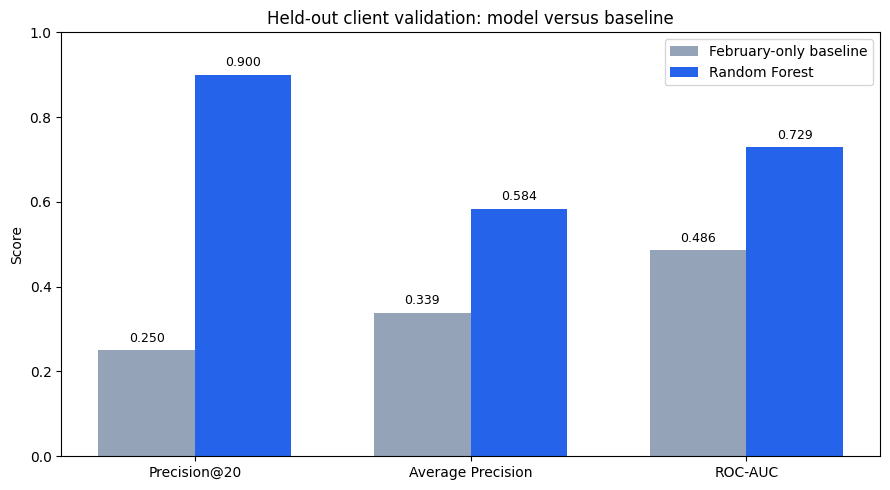

Saved public-safe aggregate chart: work/outputs/charts/model_vs_baseline.svg
The chart contains only aggregate validation metrics and is safe to reuse in the deployed paper.


In [12]:
import matplotlib.pyplot as plt
from pathlib import Path

print("=== Held-out client results ===")
display(metrics_table.round(3))

# Public-safe chart: aggregate metrics only, with no row-level information.
plot_table = metrics_table.melt(
    id_vars="metric",
    var_name="approach",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(9, 5))

metrics = metrics_table["metric"].tolist()
x = np.arange(len(metrics))
width = 0.35

baseline_scores = metrics_table["February-only baseline"].to_numpy()
model_scores = metrics_table["Random Forest"].to_numpy()

ax.bar(
    x - width / 2,
    baseline_scores,
    width,
    label="February-only baseline",
    color="#94a3b8",
)

ax.bar(
    x + width / 2,
    model_scores,
    width,
    label="Random Forest",
    color="#2563eb",
)

ax.set_title("Held-out client validation: model versus baseline")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

for index, value in enumerate(baseline_scores):
    ax.text(
        index - width / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontsize=9,
    )

for index, value in enumerate(model_scores):
    ax.text(
        index + width / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontsize=9,
    )

plt.tight_layout()

chart_dir = Path("work/outputs/charts")
chart_dir.mkdir(parents=True, exist_ok=True)

chart_path = chart_dir / "model_vs_baseline.svg"
fig.savefig(chart_path, format="svg", bbox_inches="tight")

plt.show()

print(f"Saved public-safe aggregate chart: {chart_path}")
print(
    "The chart contains only aggregate validation metrics and is safe to "
    "reuse in the deployed paper."
)

## 5. Limitations

*What this work cannot claim.*

### Model boundaries and limitations

- **Observational, not causal:** The model ranks items using observed historical patterns. It does not show that editing a title, snippet, or page will cause more clicks.
- **Proxy outcome:** The March label is whether an item's CTR was below the median CTR of comparable March position buckets. It is a prioritization proxy, not a direct measure of business impact.
- **Outcome-window selection:** The March label population requires March Search Console availability and at least 100 March impressions. This must be considered when interpreting the result.
- **Coverage:** The final grouped holdout contains 12 pseudonymized clients. Performance may differ for other clients, periods, search-result layouts, and query mixes.
- **Unobserved factors:** Query intent, SERP features, seasonality, and on-page changes are not represented fully in the February feature vector.
- **Human review required:** Recommendations are decision-support only. No site, metadata, URL, publishing, or deletion change is automated.

In [13]:
limitations = pd.DataFrame(
    [
        {
            "boundary": "Causal effect",
            "what_the_result_supports": "Observed ranking of a March CTR proxy",
            "what_it_does_not_support": "A claim that an edit will cause more clicks",
        },
        {
            "boundary": "Label definition",
            "what_the_result_supports": "Below-benchmark CTR within comparable March position buckets",
            "what_it_does_not_support": "A direct measure of business impact or user satisfaction",
        },
        {
            "boundary": "Validation coverage",
            "what_the_result_supports": "Generalization test on 12 held-out pseudonymized clients",
            "what_it_does_not_support": "Guaranteed performance for every client, period, or search context",
        },
        {
            "boundary": "Input coverage",
            "what_the_result_supports": "Directional use of February aggregate features",
            "what_it_does_not_support": "Complete representation of query intent, SERP layout, or seasonality",
        },
        {
            "boundary": "Operational use",
            "what_the_result_supports": "A ranked queue for human review",
            "what_it_does_not_support": "Automatic changes to titles, metadata, URLs, or published pages",
        },
    ]
)

print("=== Capstone limitations audit ===")
print("All findings are observational and decision-support only.")
display(limitations)

=== Capstone limitations audit ===
All findings are observational and decision-support only.


,boundary,what_the_result_supports,what_it_does_not_support
0,Causal effect,Observed ranking of a March CTR proxy,A claim that an edit will cause more clicks
1,Label definition,Below-benchmark CTR within comparable March po...,A direct measure of business impact or user sa...
2,Validation coverage,Generalization test on 12 held-out pseudonymiz...,"Guaranteed performance for every client, perio..."
3,Input coverage,Directional use of February aggregate features,"Complete representation of query intent, SERP ..."
4,Operational use,A ranked queue for human review,"Automatic changes to titles, metadata, URLs, o..."


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### April action-playbook recommendations

The February-to-March model was applied to eligible aggregated April 2026 items. Its output is a prioritization score, not an instruction to change a page automatically.

- **REVIEW_CTR_OPPORTUNITY:** High-risk items prioritized for a human review of the search snippet, page intent, and whether a content or metadata test is appropriate.
- **INVESTIGATE_HIGH_RISK:** High-risk items requiring additional diagnosis before a recommendation is made.
- **MONITOR:** Items not currently prioritized for intervention; retain for future monitoring.

The April scoring run produced 107,144 eligible items. The action queue contains 9,197 `REVIEW_CTR_OPPORTUNITY` items, 1,518 `INVESTIGATE_HIGH_RISK` items, and 96,429 `MONITOR` items. These are aggregate, public-safe counts from ML-10; no row-level queue is displayed or exported here.

Every review or investigation item requires human judgment. The model does not automatically edit titles, metadata, URLs, canonical tags, published content, or pages with legal, compliance, or brand-sensitive requirements.

In [14]:
import pandas as pd

april_action_summary = pd.DataFrame(
    [
        {
            "action_label": "REVIEW_CTR_OPPORTUNITY",
            "items": 9197,
            "human_action": "Review snippet, intent, and the possible CTR opportunity before proposing a change.",
            "automation": "No automatic changes",
        },
        {
            "action_label": "INVESTIGATE_HIGH_RISK",
            "items": 1518,
            "human_action": "Diagnose the item further before deciding whether any intervention is appropriate.",
            "automation": "No automatic changes",
        },
        {
            "action_label": "MONITOR",
            "items": 96429,
            "human_action": "Keep the item in monitoring; no current intervention is prioritized.",
            "automation": "No automatic changes",
        },
    ]
)

total_scored = int(april_action_summary["items"].sum())
review_rate = (
    april_action_summary.loc[
        april_action_summary["action_label"] == "REVIEW_CTR_OPPORTUNITY", "items"
    ].iloc[0]
    / total_scored
)

print("=== April 2026 public-safe action-playbook summary ===")
print(f"Eligible aggregated items scored: {total_scored:,}")
print(f"Human-review opportunity rate: {review_rate:.2%}")
print("All labels are decision-support only; no automatic site changes are made.")
display(april_action_summary)

=== April 2026 public-safe action-playbook summary ===
Eligible aggregated items scored: 107,144
Human-review opportunity rate: 8.58%
All labels are decision-support only; no automatic site changes are made.


,action_label,items,human_action,automation
0,REVIEW_CTR_OPPORTUNITY,9197,"Review snippet, intent, and the possible CTR o...",No automatic changes
1,INVESTIGATE_HIGH_RISK,1518,Diagnose the item further before deciding whet...,No automatic changes
2,MONITOR,96429,Keep the item in monitoring; no current interv...,No automatic changes


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

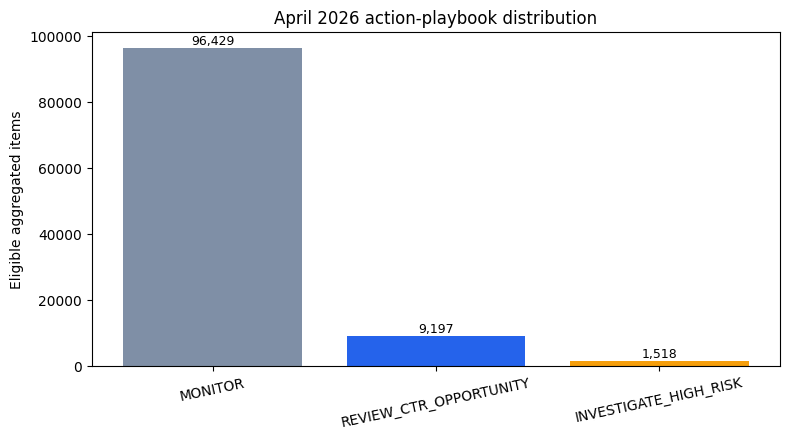


=== Public-safe paper artifacts created ===
Chart already created in Section 4: work/outputs/charts/model_vs_baseline.svg
Action distribution chart: work/outputs/charts/action_playbook_distribution.svg
Aggregate paper summary: work/outputs/capstone_paper_summary.json
No row-level recommendation queue or CSV was kept.


In [15]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

output_dir = Path("work/outputs")
chart_dir = output_dir / "charts"
chart_dir.mkdir(parents=True, exist_ok=True)

# Remove the old local row-level CSV created by the previous cell.
# It must never be committed or uploaded.
old_queue = output_dir / "refresh_queue_sample.csv"
if old_queue.exists():
    old_queue.unlink()
    print("Removed old local row-level queue CSV.")

# Create a public-safe aggregate chart of action-label counts.
plot_df = april_action_summary.sort_values("items", ascending=False).copy()

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(
    plot_df["action_label"],
    plot_df["items"],
    color=["#7f8fa6", "#2563eb", "#f59e0b"],
)
ax.set_title("April 2026 action-playbook distribution")
ax.set_ylabel("Eligible aggregated items")
ax.tick_params(axis="x", rotation=12)

for bar, value in zip(bars, plot_df["items"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
action_chart_path = chart_dir / "action_playbook_distribution.svg"
fig.savefig(action_chart_path, format="svg", bbox_inches="tight")
plt.show()

# Save only aggregate, public-safe paper metrics.
paper_summary = {
    "data_scope": "February 2026 features, March 2026 proxy label, and April 2026 aggregated action scoring",
    "validation_design": "Grouped pseudonymized-client holdout with 12 held-out clients and zero client overlap",
    "heldout_metrics": {
        "precision_at_20": {
            "february_only_baseline": 0.250,
            "random_forest": 0.900,
        },
        "average_precision": {
            "february_only_baseline": 0.339,
            "random_forest": 0.584,
        },
        "roc_auc": {
            "february_only_baseline": 0.486,
            "random_forest": 0.730,
        },
    },
    "april_action_counts": {
        "REVIEW_CTR_OPPORTUNITY": 9197,
        "INVESTIGATE_HIGH_RISK": 1518,
        "MONITOR": 96429,
    },
    "guardrail": "Recommendations are decision-support labels only; no automatic site changes are performed.",
    "limitation": "Results rank an observed position-adjusted CTR proxy and do not establish that an edit will cause more clicks.",
}

summary_path = output_dir / "capstone_paper_summary.json"
summary_path.write_text(json.dumps(paper_summary, indent=2), encoding="utf-8")

print("\n=== Public-safe paper artifacts created ===")
print(f"Chart already created in Section 4: {chart_dir / 'model_vs_baseline.svg'}")
print(f"Action distribution chart: {action_chart_path}")
print(f"Aggregate paper summary: {summary_path}")
print("No row-level recommendation queue or CSV was kept.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
